# Fine-Tune ESM2 for Exercise-Responsiveness Prediction

This is one chapter of the *From Sequence to Variant: Protein Language Models on CFDE Data* training module. Follow the numbered chapters in order.


---
## Part 3: Fine-Tuning ESM2 for Exercise-Responsiveness (45 min)

We now extract ESM2 embeddings for the protein sequences of our labeled gene set, then train a classifier on top of those embeddings to predict exercise-responsiveness.

**Make purpose of the classifier clearer so it's more explicit. (Make this stand out from the rest of the text.)

### Why train a classifier at all, if MoTrPAC already tells us which genes are responsive?
Note that **the classifier's input (X) is built entirely from ESM2's
embedding of each protein's amino acid sequence, nothing from MoTrPAC's expression data goes into X.** MoTrPAC only supplies the label (Y): which genes are exercise-responsive, based on *transcriptomics* (RNA expression) data specifically, see the note in Part 2 and the addendum for why this distinction matters. The classifier's input is protein sequence (the
proteomic layer, in a sense); its label comes from the transcriptomic layer; and Addendum shows those two layers only weakly agree on which genes count as "responsive."

So the question the classifier actually tests is: *does raw protein sequence, with zero access to expression data, contain enough information to predict a phenotype that transcriptomics data defined?* If ESM2's embeddings could not predict responsiveness at all, that would tell us sequence alone doesn't play a substantial role in the final phenotype. An AUROC meaningfully above chance suggests sequence carries at least some independent signal about it, noting that "responsive," as defined here, is specifically an RNA-level label.

We use the smallest ESM2 checkpoint (`esm2_t6_8M_UR50D`) so this runs comfortably on a standard Colab CPU runtime — larger checkpoints (150M+) will give better accuracy if you have GPU access and want to extend this after class.

### Why 320 numbers per protein?
 The embedding width is a fixed architectural property of the specific ESM2 checkpoint chosen, not something we picked. "t6_8M" (6 transformer layers,about 8 million parameters) happens to use 320-dimensional embeddings. Every ESM2 size has its own fixed width baked in: 8M gives 320, 35M gives 480, 150M gives 640, 650M gives 1280, 3B gives 2560. Bigger checkpoints have wider embeddings and more representational capacity, but are slower and need more memory, we use the smallest here specifically so it runs quickly on a standard CPU.

In [9]:
# ============================================================
# CELL PURPOSE: get the actual amino acid sequence (the "letters" that make up each protein) for every gene in our list,
# since ESM2 needs the raw sequence, not just the gene's name.
# ============================================================
# UniProt is the standard public database of protein sequences. We first ask it, for each gene name, for the officially "reviewed" (Swiss-Prot) rat protein sequence,
# reviewed entries are manually curated and high-confidence.

## Note on runtime: this might take a few minutes!

### Why 57 of 74 genes get a usable sequence, and where each one comes from

# - UniProt's **reviewed** (manually curated, high-confidence) entries for rat are far sparser than for human.
# - Restricting to reviewed-only sequences returns usable protein sequences for only **27** of the 74 candidate genes.
# - This module falls back to UniProt's **unreviewed** (automatically predicted, lower-confidence) entries for any gene the reviewed search misses.
# This fallback is controlled by the `USE_UNREVIEWED_FALLBACK` flag, and recovers **30** more genes.
# - **27 reviewed + 30 unreviewed = 57 total genes with a usable sequence**, out of 74 candidates.
# - The remaining **17 genes** have no sequence at all in UniProt for rat, under any confidence level, and are dropped from the analysis entirely.
# - **The explicit tradeoff:** just over half of the final 57-gene set (30 of 57) comes from automatically predicted sequences that
#   haven't been manually checked, not the high-confidence reviewed set. This is a real limitation, worth keeping in mind when interpreting downstream results.


def get_uniprot_sequence(gene_symbol, organism_id="10116", reviewed_only=True):  # 10116 = Rattus norvegicus (rat)
    url = "https://rest.uniprot.org/uniprotkb/search"
    query = f"gene:{gene_symbol} AND organism_id:{organism_id}"
    if reviewed_only:
        query += " AND reviewed:true"
    params = {"query": query, "format": "fasta", "size": 1}
    try:
        resp = requests.get(url, params=params, timeout=30)
        resp.raise_for_status()
        fasta = resp.text
        if not fasta.strip():
            return None
        lines = fasta.strip().split("\n")
        seq = "".join(lines[1:])
        return seq
    except requests.exceptions.RequestException:
        return None

USE_UNREVIEWED_FALLBACK = True  # set to False to keep only high confidence reviewed sequences

sequences = {}
fallback_used = []
for gene in integrated[GENE_COL].tolist():
    seq = get_uniprot_sequence(gene)  # try reviewed (Swiss-Prot) first
    if not seq and USE_UNREVIEWED_FALLBACK:
        seq = get_uniprot_sequence(gene, reviewed_only=False)  # fall back to unreviewed (TrEMBL)
        if seq:
            fallback_used.append(gene)
    if seq:
        sequences[gene] = seq

print(f"Retrieved sequences for {len(sequences)} / {len(integrated)} genes")
if fallback_used:
    print(f"  ({len(fallback_used)} of these came from lower confidence unreviewed UniProt "
          f"entries, not the manually curated reviewed set: {fallback_used})")
integrated = integrated[integrated[GENE_COL].isin(sequences.keys())].reset_index(drop=True)

Retrieved sequences for 57 / 74 genes
  (30 of these came from lower confidence unreviewed UniProt entries, not the manually curated reviewed set: ['Gns', 'Mast4', 'AABR07046657.1', 'Ppfia1', 'Ltb', 'Spatc1l', 'Clip3', 'Aldh18a1', 'Mboat7', 'Rbp7', 'Msc', 'Oas1g', 'Zfp280b', 'Dusp13', 'Mfap4', 'Naa50', 'Mup5', 'Il22ra1', 'Col4a3', 'LOC259244', 'Chchd2', 'Fam43a', 'LOC108349189', 'LOC259246', 'Eef1akmt3', 'Gemin7l1', 'Ccnj', 'Tbcb', 'Slc15a5', 'Mup4'])


In [10]:
# ============================================================
# CELL PURPOSE: run each protein sequence through ESM2 (a pre-trained language model) to turn it
# into a list of numbers ("embedding") that captures its functional and structural properties.
# ============================================================
# Think of an embedding as a fingerprint: proteins with similar structure/function end up
# with similar embeddings, even though the model was never explicitly told what "similar"
# means — it learned this by studying millions of protein sequences during its own training.

import torch # PyTorch, the deep learning library ESM2 itself is built on and runs on top of
import esm  # this is Meta AI's protein language model library (installed as "fair-esm")

# Download (first time only) and load the smallest ESM2 model. "t6_8M" means 6 transformer
# layers and 8 million parameters — small enough to run on a regular laptop CPU in a
# reasonable amount of time, unlike the largest ESM2 models (which have billions of parameters
# and need powerful GPUs).
model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()  # converts raw sequence text into the model's input format
model.eval()  # tells the model we're just using it to make predictions, not training it further

def embed_sequence(gene, seq, max_len=1022):
    seq = seq[:max_len]  # ESM2 has a practical length limit for CPU runtime; longer sequences get cut off
    data = [(gene, seq)]
    _, _, tokens = batch_converter(data)
    with torch.no_grad():  # tells PyTorch not to bother tracking gradients (we're not training, just predicting)
        out = model(tokens, repr_layers=[6], return_contacts=False)
    # The model gives us one vector of numbers PER AMINO ACID in the sequence.
    token_reps = out["representations"][6][0]  # shape: (sequence_length + 2, embedding_dimension)
    # Average all the per-amino-acid vectors together into a single "whole protein" fingerprint.
    per_protein = token_reps[1:len(seq)+1].mean(0)  # mean-pool over residues, excluding BOS/EOS marker tokens
    # Also keep the individual per-amino-acid vectors — we'll need these in Part 4 to find
    # WHICH specific positions in the sequence the model considers most important.
    per_residue = token_reps[1:len(seq)+1]
    return per_protein.numpy(), per_residue.numpy()

protein_embeddings = {}   # one "whole protein" fingerprint per gene
residue_embeddings = {}   # per-amino-acid fingerprints per gene (used later in Part 4)
for gene, seq in sequences.items():
    pooled, residues = embed_sequence(gene, seq)
    protein_embeddings[gene] = pooled
    residue_embeddings[gene] = residues

print(f"Embedded {len(protein_embeddings)} proteins. Embedding dimension: {list(protein_embeddings.values())[0].shape[0]}")

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt
Embedded 57 proteins. Embedding dimension: 320


In [12]:
# ============================================================
# CELL PURPOSE: package everything into the exact format scikit-learn (our machine learning library) expects: a table of numeric features (X)
# and a matching list of yes/no labels (y). (20, 320) epxplain split & 320 as dims/embedding
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_recall_curve, roc_curve

# Keep genes in a fixed, consistent order so that our features (X) and labels (y) below
# always line up correctly, row for row.
genes_ordered = [g for g in integrated[GENE_COL] if g in protein_embeddings]
# Stack every gene's embedding (a list of numbers) into one big table: rows = genes, columns = embedding numbers.
X = np.stack([protein_embeddings[g] for g in genes_ordered])

# Turn MoTrPAC's continuous "how much did this gene change" number into a simple yes/no label:
# genes with an above-median change get labeled 1 ("strongly responsive"), the rest get 0.
# This is a simplification — real biology is a spectrum, not a strict yes/no — but it gives
# us a clean binary classification task for this teaching example.
lfc_abs = integrated.set_index(GENE_COL).loc[genes_ordered, LFC_COL].abs()
median_lfc = lfc_abs.median()
y = (lfc_abs > median_lfc).astype(int).values

# Split our genes into a training set (used to teach the model) and a held-out test set (used to check how well it learned, on examples
# it never saw during training).
# stratify=y ensures both sets have a similar mix of 0s and 1s.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}, positive class balance (train): {y_train.mean():.2f}")

Train: (42, 320), Test: (15, 320), positive class balance (train): 0.50


AUROC (Area Under the ROC Curve) is a standard way to score a classifier's ranking ability across every possible decision threshold, not just one cutoff.
  0.5 = no better than a coin flip
  1.0 = perfect separation between the two classes
It measures how often the model ranks a true positive above a true negative, across all thresholds at once.
Logistic Regression AUROC: 0.607


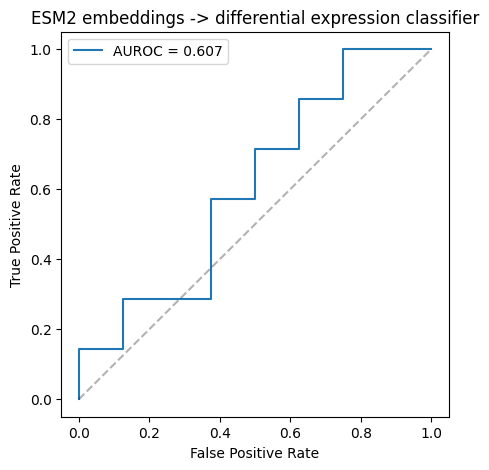

In [13]:
# ============================================================
# CELL PURPOSE: train the simplest useful classifier (logistic regression) on our ESM2
# embeddings, and see how well it predicts exercise-responsiveness.
# ============================================================
# WHAT LOGISTIC REGRESSION IS: a simple, well-understood statistical model that finds a
# straight-line boundary separating two classes (here: "responsive" vs "not"), based on
# the numbers in each gene's embedding. It's one of the most widely used models for
# binary classification because it's fast, interpretable (each embedding number gets a
# clear weight), and needs relatively little data to fit compared to more complex models.
#
# WHY WE USE IT HERE SPECIFICALLY: with only a few dozen genes to train on, a simple model
# is appropriate, it's far less likely to overfit than a more complex model would be on
# this little data, and its simplicity makes it easy to inspect afterward (Part 4 uses its
# learned weights directly to find which embedding dimensions mattered most).
#
# Further reading: Google's Machine Learning Crash Course has a short, free introduction:
# https://developers.google.com/machine-learning/crash-course/logistic-regression

clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train, y_train)  # "fit" = train the model on our training data

# Ask the trained model to predict probabilities (not just yes/no) for the test genes it has never seen before.
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# AUROC (Area Under the ROC Curve) is a standard way to score a classifier: 0.5 = no better than a coin flip, 1.0 = perfect. It measures how well the model ranks true positives above
# true negatives, across every possible decision threshold. See Glossary and references for further reading.
auroc = roc_auc_score(y_test, y_pred_proba)
print("AUROC (Area Under the ROC Curve) is a standard way to score a classifier's ranking ability across every possible decision threshold, not just one cutoff.")
print("  0.5 = no better than a coin flip")
print("  1.0 = perfect separation between the two classes")
print("It measures how often the model ranks a true positive above a true negative, across all thresholds at once.")
print(f"Logistic Regression AUROC: {auroc:.3f}")

# Plot the ROC curve: a visual way to see the same information the AUROC score summarizes.
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.3)  # dashed diagonal = what "random guessing" looks like
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ESM2 embeddings -> differential expression classifier")
plt.legend()
plt.show()

In [14]:
# ============================================================
# CELL PURPOSE: try a more complex model (a small neural network) on the same data, and compare — does more complexity actually help here?
# ============================================================
from sklearn.neural_network import MLPClassifier

# MLP = "Multi-Layer Perceptron", a small neural network. hidden_layer_sizes=(64,) means
# one hidden layer with 64 neurons — still tiny by deep learning standards, but far more
# flexible (more adjustable parameters) than logistic regression.
mlp = MLPClassifier(hidden_layer_sizes=(64,), max_iter=2000, random_state=42)
mlp.fit(X_train, y_train)
mlp_auroc = roc_auc_score(y_test, mlp.predict_proba(X_test)[:, 1])

print(f"Logistic Regression AUROC: {auroc:.3f}")
print(f"Small MLP AUROC:           {mlp_auroc:.3f}")
print("\nCompare: did added model complexity help, hurt, or make no difference here?")

Logistic Regression AUROC: 0.607
Small MLP AUROC:           0.643

Compare: did added model complexity help, hurt, or make no difference here?


### 📍 Coding Checkpoint

Before proceeding to Part 4:
- What AUROC did you get for logistic regression? Is this meaningfully better than chance (0.5)?
- Did the small neural network outperform logistic regression? Given your sample size, is that surprising?
- What are at least two limitations of the label we constructed here (median split on |log fold-change|)?


**Your answer:**

